# Reproducing `submission_feature_lag_mlp_best_candidate.csv`

This notebook rebuilds the best-scoring DengAI submission **step by step, without importing the project's `src/` or `research/` packages**.

**Recipe** (taken from `research/select_and_export_best_submission.py` and `artifacts/submission_feature_lag_mlp_best_candidate.json`):

| Part | Method |
|---|---|
| **San Juan (`sj`)** | *multiscale summary* features → 3-layer SELU MLP (`100-25`, dropout 0.3/0.7, lr 0.01), seed 42, 40 epochs × 200 steps, batch 16, MAE loss; predictions **rounded to nearest** integer |
| **Iquitos (`iq`)** | taken from the raw-lag tuned baseline (`submission_feature_lag_mlp_tuned_seed42.csv`); optionally re-trained here to check it |

Steps: 1 load data → 2 interpolate + normalise → 3 multiscale features → 4 NumPy MLP → 5 train SJ → 6 Iquitos → 7 assemble & compare with the original → 8 plot.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():          # notebook lives in DengAI/Main
    ROOT = ROOT.parent
DATA, ART = ROOT / "data", ROOT / "artifacts"
OUT = ROOT / "Main" / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

KEYS, DATE, TARGET = ["city", "year", "weekofyear"], "week_start_date", "total_cases"
SEED, EPOCHS, STEPS, BATCH = 42, 40, 200, 16
print("ROOT:", ROOT)

ROOT: /Users/targaryenaegaer/Documents/DesKTOP/MBZUAI/Project/DengAI


## 1. Load data
Training features are joined to labels; the test rows must match the submission template exactly.

In [2]:
features = pd.read_csv(DATA / "dengue_features_train.csv")
labels   = pd.read_csv(DATA / "dengue_labels_train.csv")
test     = pd.read_csv(DATA / "dengue_features_test.csv")
template = pd.read_csv(DATA / "submission_format.csv")

train = features.merge(labels, on=KEYS, how="inner", validate="one_to_one")
for df in (train, test):
    df[DATE] = pd.to_datetime(df[DATE])
assert test[KEYS].equals(template[KEYS])
print(train.shape, test.shape, template.shape)
train.groupby("city").size()

(1456, 25) (416, 24) (416, 4)


city
iq    520
sj    936
dtype: int64

## 2. Interpolate and normalise
* Missing values: global linear interpolation over each numeric column, in file order (train and test interpolated separately), exactly as the original pipeline.
* Normalisation: z-score for weather columns using **San Juan statistics for both cities** (`shared-sj`), computed on the last 53 SJ rows prepended to the SJ series. Week-of-year is min–max scaled.

In [3]:
WEATHER = [
    "precipitation_amt_mm", "reanalysis_air_temp_k", "reanalysis_avg_temp_k",
    "reanalysis_dew_point_temp_k", "reanalysis_max_air_temp_k", "reanalysis_min_air_temp_k",
    "reanalysis_precip_amt_kg_per_m2", "reanalysis_relative_humidity_percent",
    "reanalysis_sat_precip_amt_mm", "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_tdtr_k", "station_avg_temp_c", "station_diur_temp_rng_c",
    "station_max_temp_c", "station_min_temp_c", "station_precip_mm",
]

def interpolate_numeric(df):
    out = df.copy()
    num = out.select_dtypes(include="number").columns
    out[num] = out[num].interpolate(method="linear", limit_direction="forward")
    return out

def sj_normalisation(train_interp):
    sj = train_interp.loc[train_interp["city"].eq("sj")].reset_index(drop=True)
    ref = pd.concat([sj.iloc[-53:], sj], ignore_index=True)
    params = {f: (float(np.nanmean(ref[f])), float(np.nanstd(ref[f]))) for f in WEATHER}
    wk = ref["weekofyear"].to_numpy(float)
    params["weekofyear"] = (float(np.nanmin(wk)), float(np.nanmax(wk)))
    return params

def scale_columns(df, params):
    scaled = {f: (df[f].to_numpy(float) - params[f][0]) / max(params[f][1], 1e-12) for f in WEATHER}
    lo, hi = params["weekofyear"]
    scaled["weekofyear"] = (df["weekofyear"].to_numpy(float) - lo) / max(hi - lo, 1.0)
    return scaled

train_i, test_i = interpolate_numeric(train), interpolate_numeric(test)
params = sj_normalisation(train_i)
print("remaining NaNs  train:", int(train_i[WEATHER].isna().sum().sum()), " test:", int(test_i[WEATHER].isna().sum().sum()))

remaining NaNs  train: 0  test: 0


## 3. Multiscale summary features (San Juan)
For every prediction week we look at the previous 52 weeks of each of the 16 weather series and keep **11 numbers per series**:
latest value, means over 2/4/8/13/26/52 weeks, standard deviations over 4/13 weeks, the short-vs-long mean gap (`mean4 − mean13`) and the 12-week slope. Plus 4 seasonal harmonics (sin/cos of the annual and semi-annual phase).
Total: 16 × 11 + 4 = **180 features**.

Each city series is prefixed with its last 53 training rows (a circular context), and the target of row *i* is aligned to `combined[51 + i]` — a quirk of the original pipeline preserved here.

In [4]:
MEAN_WINDOWS, STD_WINDOWS = (2, 4, 8, 13, 26, 52), (4, 13)
SUMMARY_DIM = len(WEATHER) * 11 + 4

def multiscale_rows(combined, params, n_rows):
    scaled = scale_columns(combined, params)
    weeks = combined["weekofyear"].to_numpy(float)
    rows = []
    for i in range(n_rows):
        end = 51 + i
        parts = []
        for f in WEATHER:
            h = scaled[f][end - 51 : end + 1]
            m = {w: float(np.mean(h[-w:])) for w in MEAN_WINDOWS}
            parts += [float(h[-1]), *(m[w] for w in MEAN_WINDOWS),
                      *(float(np.std(h[-w:])) for w in STD_WINDOWS),
                      m[4] - m[13], float((h[-1] - h[-13]) / 12.0)]
        phase = 2 * np.pi * (weeks[end] - 1.0) / 52.0
        parts += [np.sin(phase), np.cos(phase), np.sin(2 * phase), np.cos(2 * phase)]
        rows.append(parts)
    X = np.asarray(rows, dtype="float32")
    assert X.shape == (n_rows, SUMMARY_DIM) and np.isfinite(X).all()
    return X

def city_frames(city):
    tr = train_i.loc[train_i["city"].eq(city)].reset_index(drop=True)
    te = test_i.loc[test_i["city"].eq(city)].reset_index(drop=True)
    return tr, te

def build_train(city):
    tr, _ = city_frames(city)
    combined = pd.concat([tr.iloc[-53:], tr], ignore_index=True)
    X = multiscale_rows(combined, params, len(tr))
    y = combined[TARGET].to_numpy(float)[51 : 51 + len(tr)].astype("float32")
    return X, y

def build_test(city):
    tr, te = city_frames(city)
    combined = pd.concat([tr.iloc[-53:], te], ignore_index=True)
    return multiscale_rows(combined, params, len(te))

X_sj, y_sj = build_train("sj")
Xte_sj = build_test("sj")
print("SJ train:", X_sj.shape, y_sj.shape, " SJ test:", Xte_sj.shape)

SJ train: (936, 180) (936,)  SJ test: (260, 180)


## 4. The model: a NumPy SELU MLP
Pure NumPy so the result does not depend on TensorFlow: Glorot-uniform init, two SELU hidden layers with inverted dropout, linear output, **L1 (MAE) loss** with sub-gradient `sign(error)`, RMSprop (ρ = 0.9) with per-tensor gradient clipping at ±100, and a ReduceLROnPlateau-style rule (×0.8 after 3 epochs without improvement for SJ).

In [5]:
ALPHA, SCALE = 1.6732632423543772, 1.0507009873554805
selu  = lambda x: SCALE * np.where(x > 0, x, ALPHA * np.expm1(np.clip(x, -30, 0)))
dselu = lambda x: SCALE * np.where(x > 0, 1.0, ALPHA * np.exp(np.clip(x, -30, 0)))

def fit_mlp(X, y, city, h1, h2, drop1, drop2, lr, seed, epochs=EPOCHS, steps=STEPS, batch=BATCH, val=None):
    X, y = np.asarray(X, np.float64), np.asarray(y, np.float64).reshape(-1, 1)
    rng = np.random.default_rng(seed)
    glorot = lambda i, o: rng.uniform(-np.sqrt(6 / (i + o)), np.sqrt(6 / (i + o)), (i, o))
    W = [glorot(X.shape[1], h1), np.zeros((1, h1)), glorot(h1, h2), np.zeros((1, h2)),
         glorot(h2, 1), np.zeros((1, 1))]
    cache = [np.zeros_like(w) for w in W]
    rho, eps = 0.9, 1e-7
    keep1, keep2 = 1 - drop1, 1 - drop2
    patience = 3 if city == "sj" else 5
    order, pos, best, stale = rng.permutation(len(X)), 0, np.inf, 0
    hist = []
    for ep in range(epochs):
        errs = []
        for _ in range(steps):
            if pos >= len(order):
                if city == "sj":
                    order = rng.permutation(len(X))
                pos = 0
            idx = order[pos : pos + batch]; pos += len(idx)
            xb, yb = X[idx], y[idx]
            w1, b1, w2, b2, w3, b3 = W
            z1 = xb @ w1 + b1; a1 = selu(z1)
            m1 = rng.random(a1.shape) < keep1; d1 = a1 * m1 / keep1
            z2 = d1 @ w2 + b2; a2 = selu(z2)
            m2 = rng.random(a2.shape) < keep2; d2 = a2 * m2 / keep2
            pred = d2 @ w3 + b3
            errs.append(float(np.mean(np.abs(pred - yb))))
            g = np.sign(pred - yb) / len(idx)
            dz2 = (g @ w3.T) * dselu(z2) * m2 / keep2
            dz1 = ((dz2 @ w2.T) * m1 / keep1) * dselu(z1)
            grads = [xb.T @ dz1, dz1.sum(0, keepdims=True), d1.T @ dz2,
                     dz2.sum(0, keepdims=True), d2.T @ g, g.sum(0, keepdims=True)]
            for k, gr in enumerate(grads):
                gr = np.clip(gr, -100.0, 100.0)
                cache[k] = rho * cache[k] + (1 - rho) * gr ** 2
                W[k] -= lr * gr / (np.sqrt(cache[k]) + eps)
        mae = float(np.mean(errs))
        row = {"epoch": ep + 1, "train_mae_dropout": mae, "lr": lr,
               "train_mae": float(np.mean(np.abs(predict_mlp(W, X) - y.ravel())))}
        if val is not None:
            row["val_mae"] = float(np.mean(np.abs(np.floor(np.maximum(predict_mlp(W, val[0]), 0) + .5) - val[1])))
        hist.append(row)
        if mae < best:
            best, stale = mae, 0
        else:
            stale += 1
        if stale >= patience:
            lr, stale = max(lr * 0.8, 1e-6), 0
    return W, pd.DataFrame(hist)

def predict_mlp(W, X):
    w1, b1, w2, b2, w3, b3 = W
    return (selu(selu(np.asarray(X, np.float64) @ w1 + b1) @ w2 + b2) @ w3 + b3).reshape(-1)

## 5. Train San Juan and predict
Tuned SJ config: hidden 100 → 25, dropout 0.3 / 0.7, learning rate 0.01. Roughly a minute on CPU.

In [6]:
%%time
W_sj, hist_sj = fit_mlp(X_sj, y_sj, "sj", h1=100, h2=25, drop1=0.3, drop2=0.7, lr=0.01, seed=SEED)
train_mae = np.mean(np.abs(predict_mlp(W_sj, X_sj) - y_sj))
raw_sj = predict_mlp(W_sj, Xte_sj)

# selected strategy: rounding="nearest" (clip at 0, then floor(x + 0.5))
sj_cases = np.floor(np.maximum(raw_sj, 0.0) + 0.5).astype(int)
print(f"SJ train MAE: {train_mae:.3f}   predictions: min={sj_cases.min()} median={np.median(sj_cases):.0f} mean={sj_cases.mean():.2f} max={sj_cases.max()}")

SJ train MAE: 6.972   predictions: min=4 median=16 mean=48.39 max=233
CPU times: user 1.63 s, sys: 124 ms, total: 1.75 s
Wall time: 1.77 s


## 6. Iquitos
The selected strategy has `iq_from_baseline = true`: Iquitos predictions are copied from the raw-lag tuned baseline submission (`submission_feature_lag_mlp_tuned_seed42.csv`, a different feature representation: per-feature lag windows, 70-18 MLP).
That file is the one external input of this notebook.

In [7]:
baseline = pd.read_csv(ART / "submission_feature_lag_mlp_tuned_seed42.csv")
iq_test = test.loc[test["city"].eq("iq")].sort_values(DATE).reset_index(drop=True)
iq_cases = baseline.loc[baseline["city"].eq("iq"), TARGET].to_numpy(int)
assert len(iq_cases) == len(iq_test)
print("IQ from baseline:", len(iq_cases), "weeks, mean", iq_cases.mean().round(2))

IQ from baseline: 156 weeks, mean 4.78


## 7. Assemble the submission and compare with the original
Rows are put in the template order, then compared cell by cell with `artifacts/submission_feature_lag_mlp_best_candidate.csv`.

In [8]:
def prediction_frame(city, cases):
    ct = test.loc[test["city"].eq(city)].sort_values(DATE).reset_index(drop=True)
    out = ct[KEYS].copy(); out[TARGET] = np.asarray(cases, int)
    return out

preds = pd.concat([prediction_frame("sj", sj_cases), prediction_frame("iq", iq_cases)], ignore_index=True)
submission = template[KEYS].merge(preds, on=KEYS, how="left", validate="one_to_one", sort=False)
assert submission[TARGET].notna().all() and submission[KEYS].equals(template[KEYS])
submission[TARGET] = submission[TARGET].astype(int)

out_path = OUT / "submission_feature_lag_mlp_best_candidate_reproduced.csv"
submission.to_csv(out_path, index=False)

original = pd.read_csv(ART / "submission_feature_lag_mlp_best_candidate.csv")
cmp = submission.merge(original, on=KEYS, suffixes=("_new", "_orig"))
diff = (cmp[f"{TARGET}_new"] - cmp[f"{TARGET}_orig"]).abs()
print("identical file contents:", submission.equals(original))
print(f"rows differing: {(diff > 0).sum()} / {len(diff)}   mean |diff|: {diff.mean():.4f}   max |diff|: {diff.max()}")
print(cmp.assign(diff=diff).groupby("city")["diff"].agg(["mean", "max", lambda s: (s > 0).sum()]).rename(columns={"<lambda_0>": "n_diff"}))

identical file contents: True
rows differing: 0 / 416   mean |diff|: 0.0000   max |diff|: 0
      mean  max  n_diff
city                   
iq     0.0    0       0
sj     0.0    0       0


## 8. Plot: reproduced vs original

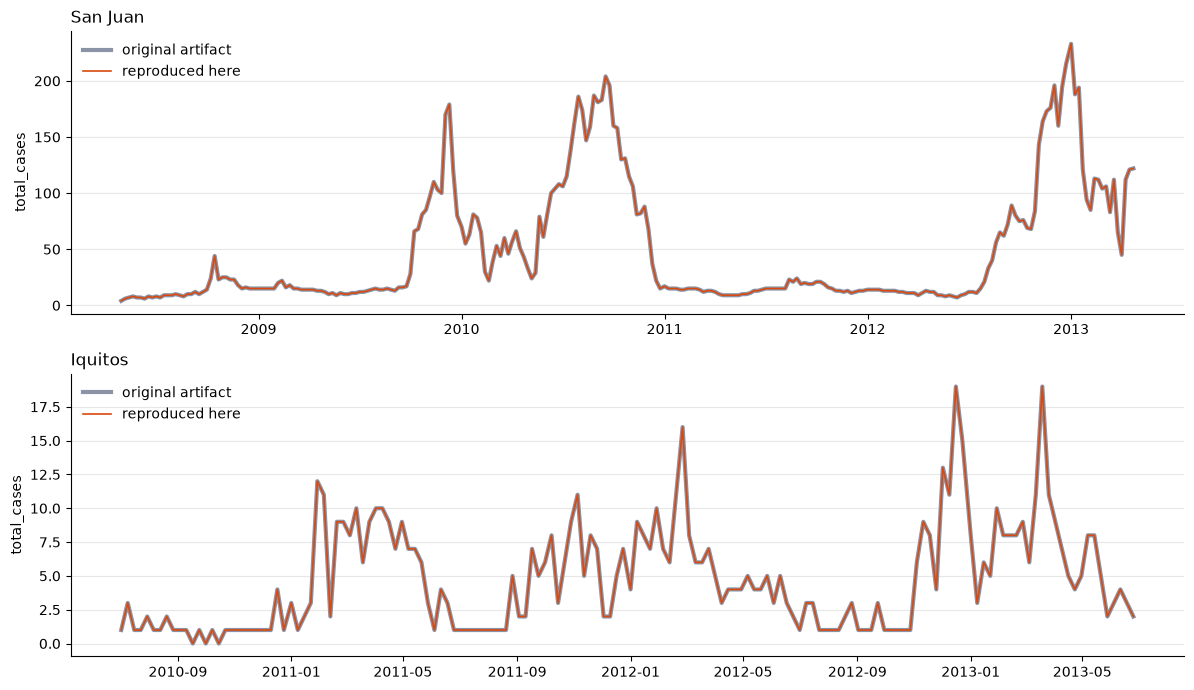

In [9]:
cmp = cmp.merge(test[KEYS + [DATE]], on=KEYS)
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (city, name) in zip(axes, [("sj", "San Juan"), ("iq", "Iquitos")]):
    d = cmp[cmp["city"].eq(city)].sort_values(DATE)
    ax.plot(d[DATE], d[f"{TARGET}_orig"], color="#8a94a6", lw=3, label="original artifact")
    ax.plot(d[DATE], d[f"{TARGET}_new"], color="#d9480f", lw=1.2, label="reproduced here")
    ax.set_title(name, loc="left"); ax.set_ylabel(TARGET); ax.legend(frameon=False)
    ax.grid(axis="y", alpha=.3); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

## 8b. Training curves (final SJ model)
`train_mae_dropout` is the running MAE seen during training (dropout active, what the learning-rate rule monitors); `train_mae` is the clean in-sample MAE after each epoch.

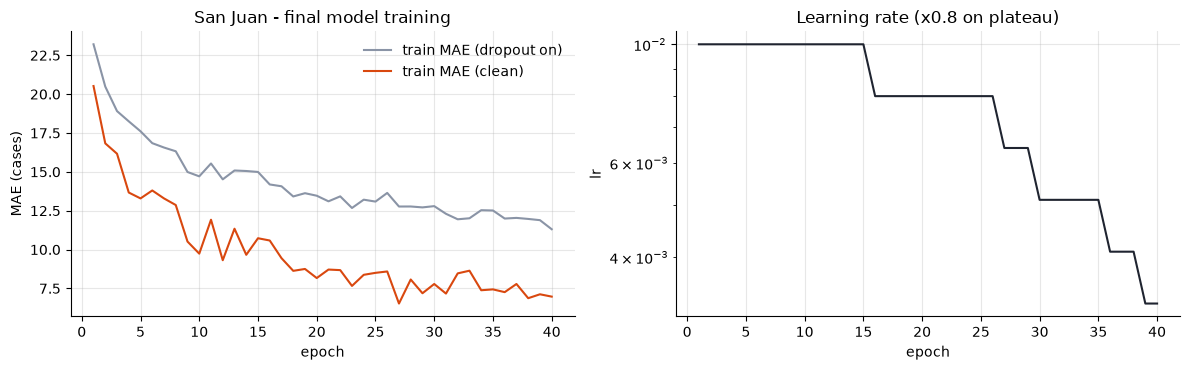

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(hist_sj.epoch, hist_sj.train_mae_dropout, color="#8a94a6", label="train MAE (dropout on)")
ax[0].plot(hist_sj.epoch, hist_sj.train_mae, color="#d9480f", label="train MAE (clean)")
ax[0].set(title="San Juan - final model training", xlabel="epoch", ylabel="MAE (cases)"); ax[0].legend(frameon=False)
ax[1].plot(hist_sj.epoch, hist_sj.lr, color="#1f2430"); ax[1].set_yscale("log")
ax[1].set(title="Learning rate (x0.8 on plateau)", xlabel="epoch", ylabel="lr")
for a in ax:
    a.grid(alpha=.3); [a.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

## 8c. Validation: chronological 52-week hold-out (San Juan)
This is the selection step of the original script: train on all SJ weeks except the last 52, with the shorter CV schedule (28 epochs x 120 steps), and score on the held-out year with the same nearest-integer rounding. The original JSON reports **hold-out MAE = 16.519** for this strategy.

In [11]:
%%time
HOLD = 52
sj_all = train_i.loc[train_i["city"].eq("sj")].sort_values(DATE).reset_index(drop=True)
cut = len(sj_all) - HOLD
fold_train, hold_frame = train_i.loc[train_i["city"].eq("sj")].sort_values(DATE).iloc[:cut], sj_all.iloc[cut:]
# parameters/context come from the fold's own training rows (as in the original, which re-runs the pipeline on the fold)
raw_fold = train.loc[train["city"].eq("sj")].sort_values(DATE).reset_index(drop=True).iloc[:cut]
hold_raw = train.loc[train["city"].eq("sj")].sort_values(DATE).reset_index(drop=True).iloc[cut:]
iq_raw = train.loc[train["city"].eq("iq")].sort_values(DATE)
iq_end = max(53, int(len(iq_raw) * cut / len(sj_all)))
fold_df = pd.concat([raw_fold, iq_raw.iloc[:iq_end]], ignore_index=True)

# rebuild features for the fold with the same functions (globals swapped temporarily)
_tr, _te, _p = train_i, test_i, params
train_i = interpolate_numeric(fold_df); test_i = interpolate_numeric(hold_raw.drop(columns=[TARGET]))
params = sj_normalisation(train_i)
Xf, yf = build_train("sj"); Xh = build_test("sj")
train_i, test_i, params = _tr, _te, _p
yh = hold_raw[TARGET].to_numpy(float)

W_cv, hist_cv = fit_mlp(Xf, yf, "sj", 100, 25, 0.3, 0.7, 0.01, SEED, epochs=28, steps=120, val=(Xh, yh))
hold_pred = np.floor(np.maximum(predict_mlp(W_cv, Xh), 0) + .5)
print(f"hold-out MAE: {np.mean(np.abs(hold_pred - yh)):.3f}   (original JSON: 16.519)")

hold-out MAE: 16.519   (original JSON: 16.519)
CPU times: user 1.05 s, sys: 63.1 ms, total: 1.11 s
Wall time: 1.12 s


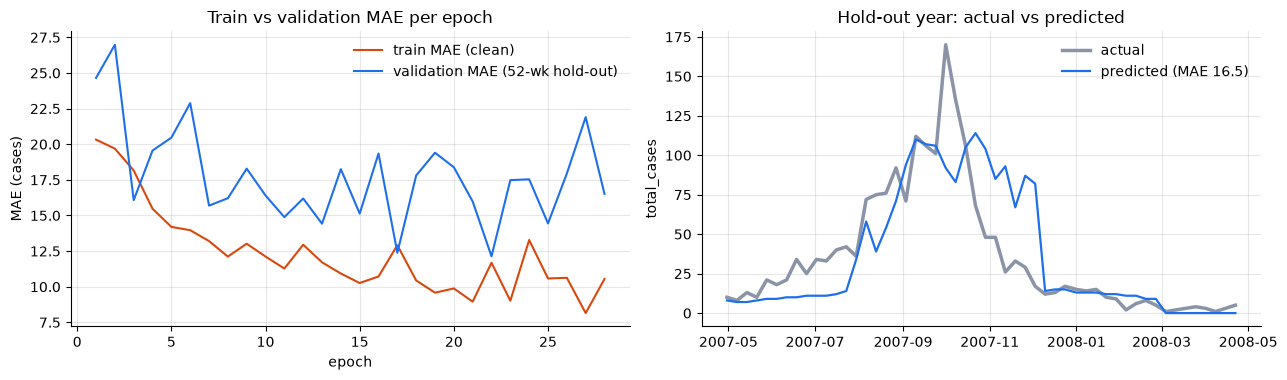

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
ax[0].plot(hist_cv.epoch, hist_cv.train_mae, color="#d9480f", label="train MAE (clean)")
ax[0].plot(hist_cv.epoch, hist_cv.val_mae, color="#1f6feb", label="validation MAE (52-wk hold-out)")
ax[0].set(title="Train vs validation MAE per epoch", xlabel="epoch", ylabel="MAE (cases)"); ax[0].legend(frameon=False)
d = hold_raw[DATE].to_numpy()
ax[1].plot(d, yh, color="#8a94a6", lw=2.5, label="actual")
ax[1].plot(d, hold_pred, color="#1f6feb", lw=1.6, label=f"predicted (MAE {np.mean(np.abs(hold_pred-yh)):.1f})")
ax[1].set(title="Hold-out year: actual vs predicted", ylabel="total_cases"); ax[1].legend(frameon=False)
for a in ax:
    a.grid(alpha=.3); [a.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

## 9. (Optional) Re-train Iquitos from scratch
To check whether the Iquitos baseline itself is reproducible, this cell re-trains the raw-lag tuned model (per-feature lag windows, MLP 70-18, dropout 0.5/0.5, lr 0.001, seed 42) with the same NumPy trainer and compares it to the baseline CSV. Set `RUN_IQ_RETRAIN = True` to run it.

In [13]:
RUN_IQ_RETRAIN = False

LAG_IQ = {"precipitation_amt_mm": 33, "reanalysis_air_temp_k": 10, "reanalysis_avg_temp_k": 4,
          "reanalysis_dew_point_temp_k": 6, "reanalysis_max_air_temp_k": 41, "reanalysis_min_air_temp_k": 40,
          "reanalysis_precip_amt_kg_per_m2": 3, "reanalysis_relative_humidity_percent": 7,
          "reanalysis_sat_precip_amt_mm": 33, "reanalysis_specific_humidity_g_per_kg": 26,
          "reanalysis_tdtr_k": 34, "station_avg_temp_c": 40, "station_diur_temp_rng_c": 26,
          "station_max_temp_c": 39, "station_min_temp_c": 25, "station_precip_mm": 10, "weekofyear": 3}

def raw_lag_rows(combined, n_rows):
    sc = scale_columns(combined, params)
    rows = [np.concatenate([sc[f][51 + i - w + 1 : 51 + i + 1] for f, w in LAG_IQ.items()]) for i in range(n_rows)]
    return np.vstack(rows).astype("float32")

if RUN_IQ_RETRAIN:
    tr, te = city_frames("iq")
    comb_tr = pd.concat([tr.iloc[-53:], tr], ignore_index=True)
    Xi, yi = raw_lag_rows(comb_tr, len(tr)), comb_tr[TARGET].to_numpy(float)[51 : 51 + len(tr)]
    Xi_te = raw_lag_rows(pd.concat([tr.iloc[-53:], te], ignore_index=True), len(te))
    W_iq, _ = fit_mlp(Xi, yi, "iq", 70, 18, 0.5, 0.5, 0.001, SEED)
    iq_re = np.maximum(predict_mlp(W_iq, Xi_te), 0).astype(int)      # baseline used truncation
    print("mean |retrained - baseline|:", np.abs(iq_re - iq_cases).mean().round(3), " identical:", np.array_equal(iq_re, iq_cases))